In [ ]:
!pip install lime shap

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

import torch
from torch.utils.data import Dataset

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, Bidirectional, LSTM, Dense

from lime.lime_text import LimeTextExplainer
import shap

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

#load dataset
train_df = pd.read_csv('/content/drive/MyDrive/Machine_Learning/Train.csv')
val_df   = pd.read_csv('/content/drive/MyDrive/Machine_Learning/Val.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/Machine_Learning/Test.csv')

In [ ]:
#cleaning
for df in [train_df, val_df, test_df]:
    df.drop_duplicates(inplace=True)
    df.dropna(inplace=True)

In [ ]:
train_texts = set(train_df['Data'])

val_df  = val_df[~val_df['Data'].isin(train_texts)]
test_df = test_df[~test_df['Data'].isin(train_texts)]

In [ ]:
#preprocessing
def clean_text(text):
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^\u0980-\u09FF\s]", "", text)
    return text.strip()

for df in [train_df, val_df, test_df]:
    df['Data'] = df['Data'].apply(clean_text)

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2437 (\N{BENGALI LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2459 (\N{BENGALI LETTER CHA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2474 (\N{BENGALI LETTER PA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-pack

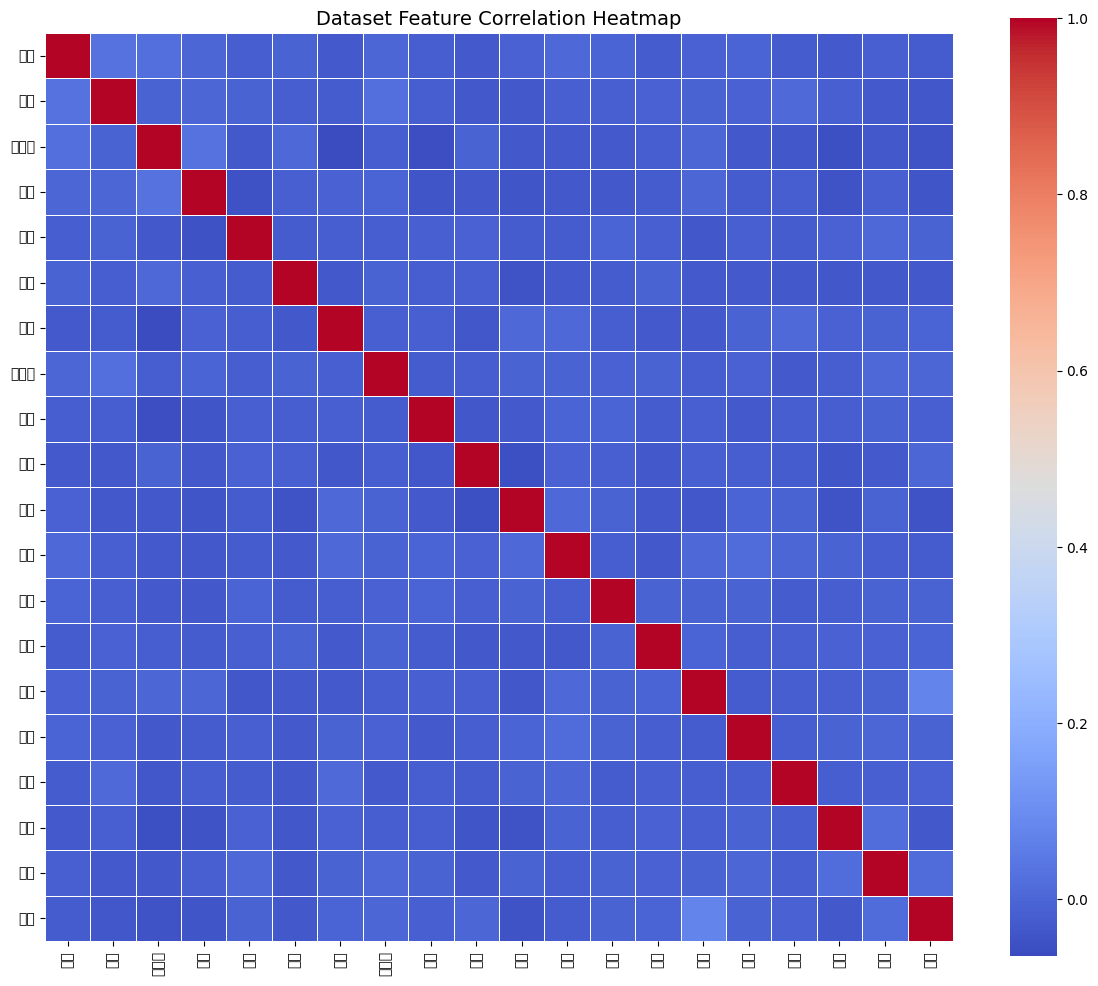

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2447 (\N{BENGALI LETTER E}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2439 (\N{BENGALI LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2453 (\N{BENGALI LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packag

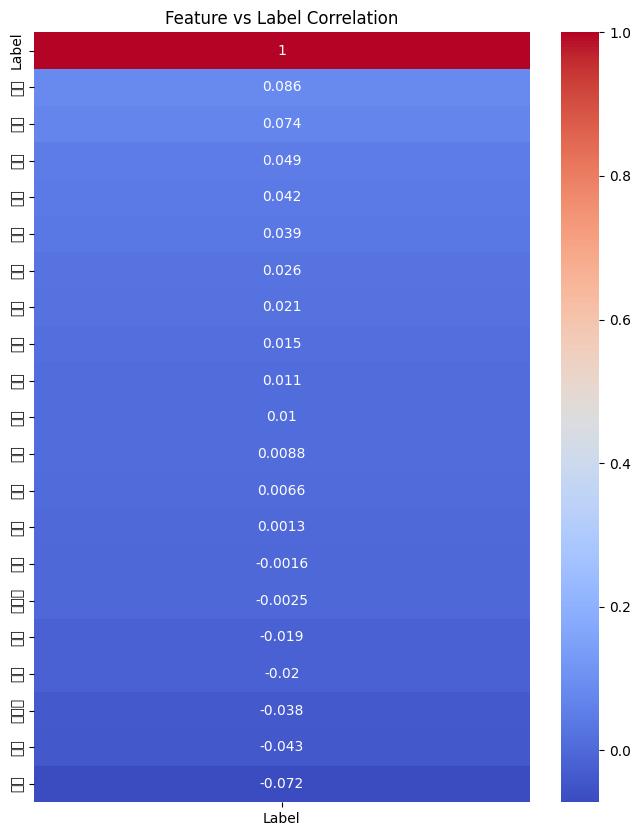


Top Positive Correlated Words:

          Label
Label  1.000000
আর     0.085594
এই     0.074012
কর     0.048527
হয়     0.041997
এর     0.038612
সব     0.026018
হল     0.020719
জন     0.015102
বল     0.011473

Top Negative Correlated Words:

        Label
মন   0.008799
হব   0.006577
পর   0.001323
আছ  -0.001625
একট -0.002537
ওয়  -0.018713
অন  -0.020182
আপন -0.038040
ইয়  -0.042767
আম  -0.072280


In [ ]:
#heatmap
# ===============================
# 📦 IMPORTS
# ===============================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# ===============================
# 📂 LOAD DATASET
# ===============================
# train_df = pd.read_csv('/content/Train.csv') # This line is redundant as train_df is already loaded.

# ===============================
# 🧹 CLEANING (optional but recommended)
# ===============================
train_df.drop_duplicates(inplace=True)
train_df.dropna(inplace=True)

# ===============================
# 🔤 TEXT → TF-IDF FEATURES
# ===============================
vectorizer = TfidfVectorizer(max_features=20)  # 🔥 20 features for clean heatmap
X_tfidf = vectorizer.fit_transform(train_df['Data'])

# Convert to DataFrame
df_tfidf = pd.DataFrame(
    X_tfidf.toarray(),
    columns=vectorizer.get_feature_names_out()
)

# ===============================
# 🔥 1. FEATURE vs FEATURE HEATMAP
# ===============================
corr_matrix = df_tfidf.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=False,
    linewidths=0.5,
    square=True,
    cbar=True
)

plt.title("Dataset Feature Correlation Heatmap", fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

# Save high-quality image
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')

plt.show()


# ===============================
# 🔥 2. FEATURE vs LABEL HEATMAP
# ===============================

# Add label column
df_tfidf['Label'] = train_df['Label'].reset_index(drop=True)

# Compute correlation
corr_with_label = df_tfidf.corr()[['Label']].sort_values(by='Label', ascending=False)

plt.figure(figsize=(8,10))
sns.heatmap(corr_with_label, cmap='coolwarm', annot=True)
plt.title("Feature vs Label Correlation")
plt.show()


# ===============================
# 🔥 3. TOP IMPORTANT FEATURES PRINT
# ===============================
print("\nTop Positive Correlated Words:\n")
print(corr_with_label.head(10))

print("\nTop Negative Correlated Words:\n")
print(corr_with_label.tail(10))

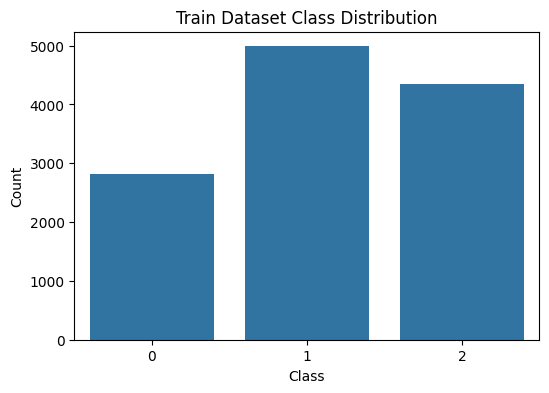

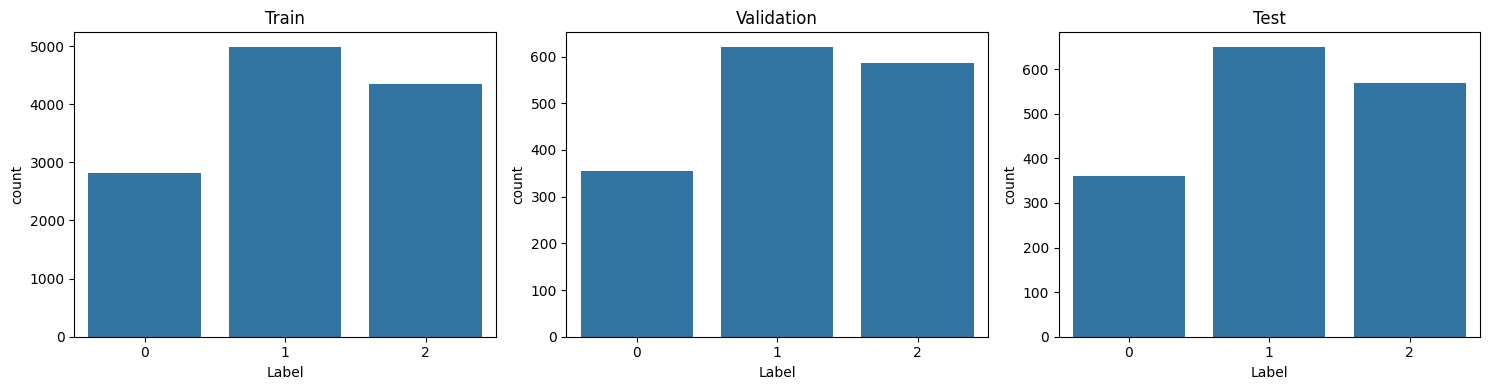

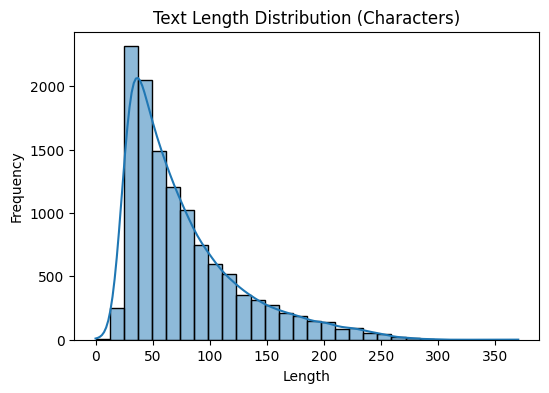

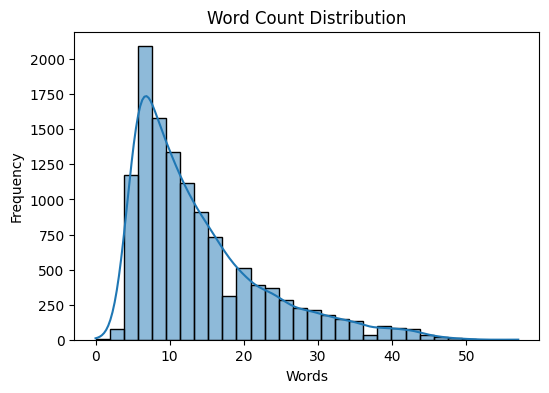

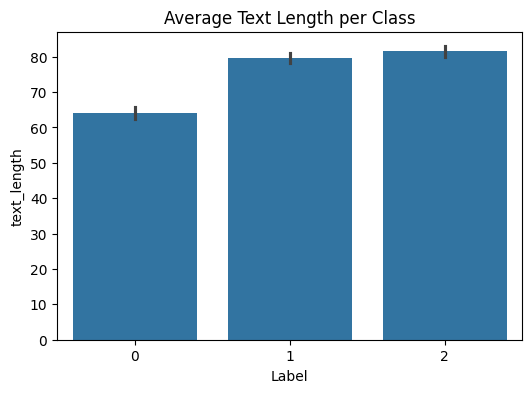

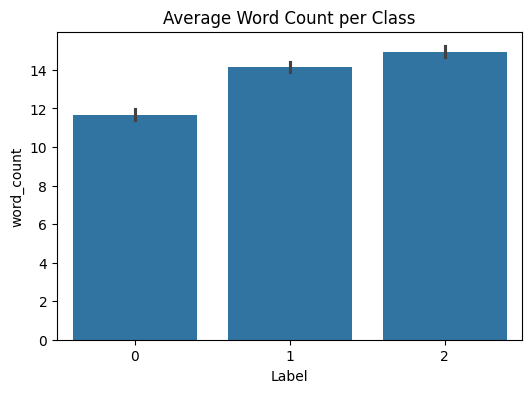

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2477 (\N{BENGALI LETTER BHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2439 (\N{BENGALI LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dis

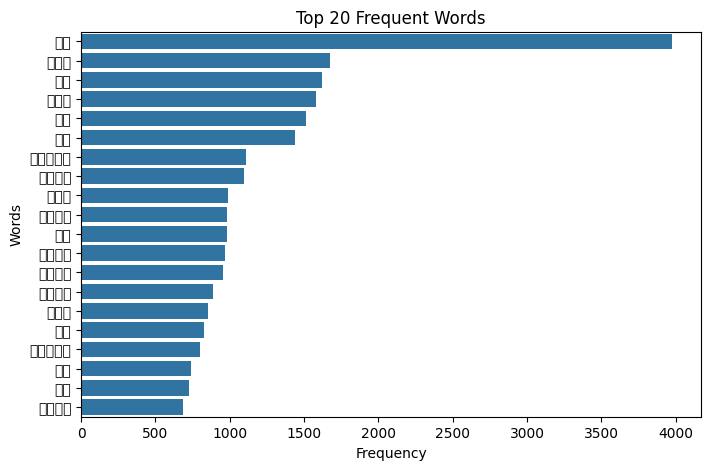

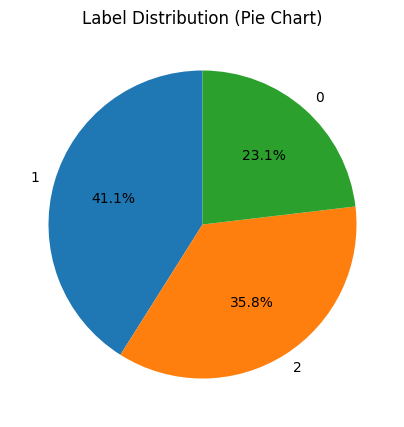

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# =========================
# LOAD DATASET
# =========================
train_df = pd.read_csv('/content/drive/MyDrive/Machine_Learning/Train.csv')
val_df   = pd.read_csv('/content/drive/MyDrive/Machine_Learning/Val.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/Machine_Learning/Test.csv')

# =========================
# CLEAN NULL + DUPLICATES
# =========================
for df in [train_df, val_df, test_df]:
    df.drop_duplicates(inplace=True)
    df.dropna(inplace=True)

# =========================
# BASIC CLEAN TEXT (optional for EDA)
# =========================
def clean_text(text):
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^\u0980-\u09FF\s]", "", text)
    return text.strip()

for df in [train_df, val_df, test_df]:
    df['Data'] = df['Data'].apply(clean_text)

# =========================================================
# 1️⃣ CLASS DISTRIBUTION (MOST IMPORTANT)
# =========================================================
plt.figure(figsize=(6,4))
sns.countplot(x='Label', data=train_df)
plt.title("Train Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# =========================================================
# 2️⃣ TRAIN / VAL / TEST COMPARISON
# =========================================================
fig, ax = plt.subplots(1, 3, figsize=(15,4))

sns.countplot(x='Label', data=train_df, ax=ax[0])
ax[0].set_title("Train")

sns.countplot(x='Label', data=val_df, ax=ax[1])
ax[1].set_title("Validation")

sns.countplot(x='Label', data=test_df, ax=ax[2])
ax[2].set_title("Test")

plt.tight_layout()
plt.show()

# =========================================================
# 3️⃣ TEXT LENGTH DISTRIBUTION (CHARACTER LEVEL)
# =========================================================
train_df['text_length'] = train_df['Data'].apply(len)

plt.figure(figsize=(6,4))
sns.histplot(train_df['text_length'], bins=30, kde=True)
plt.title("Text Length Distribution (Characters)")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

# =========================================================
# 4️⃣ WORD COUNT DISTRIBUTION
# =========================================================
train_df['word_count'] = train_df['Data'].apply(lambda x: len(x.split()))

plt.figure(figsize=(6,4))
sns.histplot(train_df['word_count'], bins=30, kde=True)
plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

# =========================================================
# 5️⃣ AVERAGE TEXT LENGTH PER CLASS
# =========================================================
plt.figure(figsize=(6,4))
sns.barplot(x='Label', y='text_length', data=train_df)
plt.title("Average Text Length per Class")
plt.show()

# =========================================================
# 6️⃣ AVERAGE WORD COUNT PER CLASS
# =========================================================
plt.figure(figsize=(6,4))
sns.barplot(x='Label', y='word_count', data=train_df)
plt.title("Average Word Count per Class")
plt.show()

# =========================================================
# 7️⃣ TOP 20 FREQUENT WORDS
# =========================================================
all_words = " ".join(train_df['Data']).split()
word_freq = Counter(all_words).most_common(20)

words = [w[0] for w in word_freq]
counts = [w[1] for w in word_freq]

plt.figure(figsize=(8,5))
sns.barplot(x=counts, y=words)
plt.title("Top 20 Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

# =========================================================
# 8️⃣ LABEL PIE CHART (OPTIONAL BUT NICE)
# =========================================================
plt.figure(figsize=(5,5))
train_df['Label'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Label Distribution (Pie Chart)")
plt.ylabel("")
plt.show()

In [ ]:
#define data
X_train = train_df['Data']
y_train = train_df['Label']

X_val = val_df['Data']
y_val = val_df['Label']

X_test = test_df['Data']

In [ ]:
# =========================================
# 🔥 IMPROVED XLM-R SENTIMENT CLASSIFICATION
# =========================================

!pip install -q transformers datasets scikit-learn accelerate

import pandas as pd
import numpy as np
import torch
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

# =========================================
# 🧹 TEXT CLEANING
# =========================================
def clean_text(text):
    text = re.sub(r"http\S+", "", text)  # URL রিমুভ
    text = re.sub(r"[^\u0980-\u09FF\s]", "", text) # শুধু বাংলা অক্ষর রাখা (ঐচ্ছিক, যদি ডেটা শুধু বাংলা হয়)
    text = " ".join(text.split()) # এক্সট্রা স্পেস রিমুভ
    return text

df['Data'] = df['Data'].apply(clean_text)

# =========================================
# 📊 DATA PREPARATION
# =========================================
# Stratify ব্যবহার করা হয়েছে যাতে সব ক্লাসের অনুপাত ঠিক থাকে
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['Data'], df['Label'], test_size=0.15, stratify=df['Label'], random_state=42
)

# =========================================
# 🔤 TOKENIZER
# =========================================
model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_data(texts):
    return tokenizer(
        list(texts),
        padding='max_length',
        truncation=True,
        max_length=128
    )

train_encodings = tokenize_data(train_texts)
val_encodings = tokenize_data(val_texts)

# =========================================
# 📦 DATASET CLASS
# =========================================
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.reset_index(drop=True)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, train_labels)
val_dataset = SentimentDataset(val_encodings, val_labels)

# =========================================
# ⚖️ HANDLING CLASS IMBALANCE (Optional but recommended)
# =========================================
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(weights, dtype=torch.float)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

# =========================================
# 🧠 MODEL & TRAINING CONFIG
# =========================================
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

training_args = TrainingArguments(
    output_dir="./results_xlm_optimized",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,               # Transformers এর জন্য আদর্শ লার্নিং রেট
    per_device_train_batch_size=16,   # মেমরি থাকলে ১৬ রাখুন, নাহলে ৮
    per_device_eval_batch_size=16,
    num_train_epochs=5,               # ইপোক বাড়িয়ে ৫ করা হয়েছে
    weight_decay=0.01,                # Overfitting কমানোর জন্য
    warmup_ratio=0.1,                 # শুরুর দিকে লার্নিং রেট ধীরে বাড়বে
    load_best_model_at_end=True,      # সেরা মডেলটি শেষে লোড হবে
    metric_for_best_model="f1",
    fp16=True if torch.cuda.is_available() else False,
    logging_steps=50,
)

def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted")
    }

# =========================================
# 🚀 TRAIN
# =========================================
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)] # ২ ইপোক ইমপ্রুভ না হলে থেমে যাবে
)

trainer.train()

# =========================================
# 📊 EVALUATE
# =========================================
results = trainer.predict(val_dataset)
y_pred = np.argmax(results.predictions, axis=1)

print("\n🔥 Optimized XLM-R Classification Report:\n")
print(classification_report(val_labels, y_pred))

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


🔥 Optimized XLM-R Classification Report:

              precision    recall  f1-score   support

           0       0.44      0.31      0.37        54
           1       0.60      0.77      0.67        98
           2       0.69      0.59      0.64        86

    accuracy                           0.60       238
   macro avg       0.58      0.56      0.56       238
weighted avg       0.59      0.60      0.59       238



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# =========================================
# 1️⃣ CONFUSION MATRIX
# =========================================
# Validation data er upor prediction neya
preds_output = trainer.predict(val_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = val_labels.values

cm = confusion_matrix(y_true, y_pred)
labels = ['Funny', 'Toxic', 'Sad'] # Apnar dataset er class name onujayi change korte paren

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='mako',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Optimized XLM-R')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# =========================================
# 2️⃣ VALIDATION CURVE (LOSS & ACCURACY)
# =========================================
# Trainer er state theke log history neya
history = trainer.state.log_history

# Loss ebong Accuracy data filter kora
train_loss = [x['loss'] for x in history if 'loss' in x]
val_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
val_acc = [x['eval_accuracy'] for x in history if 'eval_accuracy' in x]

plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train Loss', color='blue', linestyle='--', marker='o')
plt.plot(val_loss, label='Validation Loss', color='red', linestyle='-', marker='s')
plt.title('Training & Validation Loss')
plt.xlabel('Steps/Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(val_acc, label='Validation Accuracy', color='green', marker='^')
plt.title('Validation Accuracy over Time')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# =========================================
# 3️⃣ ROC CURVE (MULTI-CLASS)
# =========================================
# Predictions probability calculate kora
probs = torch.nn.functional.softmax(torch.tensor(preds_output.predictions), dim=1).numpy()

# Label binarize kora (One-vs-Rest)
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
n_classes = y_true_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot kora
plt.figure(figsize=(9, 7))
colors = ['cyan', 'magenta', 'orange']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {labels[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve - XLM-R')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

In [ ]:
#SVM Model
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

X = train_df['Data'].values
y = train_df['Label'].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_scores = []
f1_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n===== Fold {fold+1} =====")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    vectorizer = TfidfVectorizer(max_features=5000)
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_val_tfidf = vectorizer.transform(X_val)

    model = SVC(probability=True)
    model.fit(X_train_tfidf, y_train)

    preds = model.predict(X_val_tfidf)

    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds, average='weighted')

    acc_scores.append(acc)
    f1_scores.append(f1)

    print("Accuracy:", acc)
    print("F1:", f1)

print("\nFINAL RESULT")
print("Mean Accuracy:", np.mean(acc_scores))
print("Mean F1:", np.mean(f1_scores))


===== Fold 1 =====
Accuracy: 0.5973651708522025
F1: 0.5779847000550942

===== Fold 2 =====
Accuracy: 0.5998353231782627
F1: 0.5712829651823035

===== Fold 3 =====
Accuracy: 0.5944833264717991
F1: 0.5748938758475444

===== Fold 4 =====
Accuracy: 0.599011939069576
F1: 0.5692095626436804

===== Fold 5 =====
Accuracy: 0.5833676410045286
F1: 0.5545862551309161

FINAL RESULT
Mean Accuracy: 0.5948126801152738
Mean F1: 0.5695914717719077


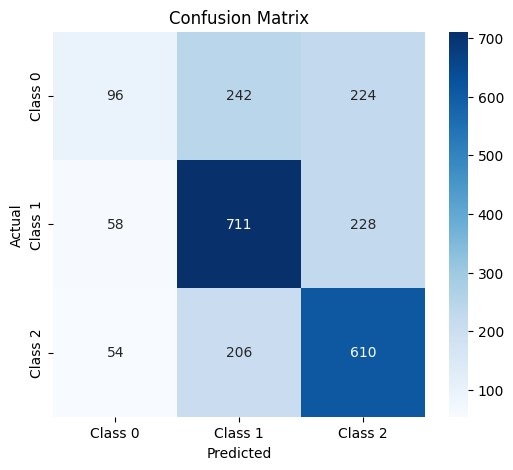

In [ ]:
#svm confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, preds)
labels = ['Class 0', 'Class 1', 'Class 2']

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

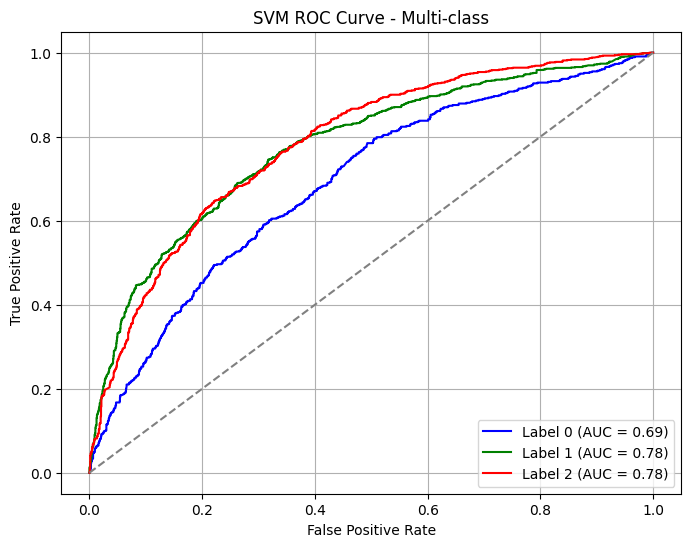

In [ ]:
#SVM Roc curve

# Re-vectorize and train a single SVM model for ROC plotting
# This ensures compatibility between the vectorizer and the model's expected features.
vectorizer_roc = TfidfVectorizer(max_features=5000) # Use same max_features as in Pwi0cF4qpIbp
X_train_tfidf_roc = vectorizer_roc.fit_transform(X_train)
X_val_tfidf_roc = vectorizer_roc.transform(X_val)

svm_roc = SVC(probability=True)
svm_roc.fit(X_train_tfidf_roc, y_train)

# Binarize labels (using the global y_val)
y_val_bin = label_binarize(y_val, classes=[0,1,2])
y_score = svm_roc.predict_proba(X_val_tfidf_roc)

# Define colors and class names
colors = ['blue', 'green', 'red']
class_names = ['Label 0', 'Label 1', 'Label 2']

plt.figure(figsize=(8,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], color='gray', linestyle='--')  # Diagonal line
plt.title("SVM ROC Curve - Multi-class")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

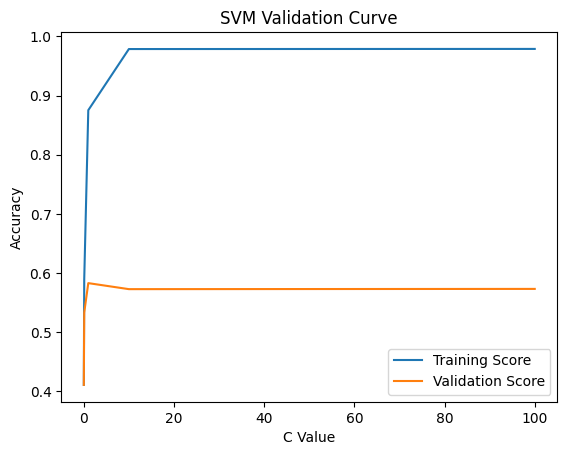

In [ ]:
#validation curve
from sklearn.model_selection import validation_curve

param_range = [0.01, 0.1, 1, 10, 100]

train_scores, val_scores = validation_curve(
    SVC(),
    X_train_tfidf,
    y_train,
    param_name="C",
    param_range=param_range,
    cv=3,
    scoring="accuracy"
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.plot(param_range, train_mean, label="Training Score")
plt.plot(param_range, val_mean, label="Validation Score")

plt.xlabel("C Value")
plt.ylabel("Accuracy")
plt.title("SVM Validation Curve")
plt.legend()
plt.show()

In [ ]:
#BiLSTM Model
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, Bidirectional, LSTM, Dense
import numpy as np

X = train_df['Data'].values
y = train_df['Label'].values

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

acc_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n===== Fold {fold+1} =====")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    tokenizer = Tokenizer(num_words=5000)
    tokenizer.fit_on_texts(X_train)

    X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=100)
    X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=100)

    model = Sequential()
    model.add(Embedding(5000, 128))
    model.add(Bidirectional(LSTM(64)))
    model.add(Dense(3, activation='softmax'))

    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

    model.fit(X_train_seq, y_train,
              validation_data=(X_val_seq, y_val),
              epochs=3,
              verbose=0)

    loss, acc = model.evaluate(X_val_seq, y_val, verbose=0)
    acc_scores.append(acc)

    print("Fold Accuracy:", acc)

print("\nMean Accuracy:", np.mean(acc_scores))


===== Fold 1 =====
Fold Accuracy: 0.6233637928962708

===== Fold 2 =====
Fold Accuracy: 0.6363636255264282

===== Fold 3 =====
Fold Accuracy: 0.6383399367332458

Mean Accuracy: 0.6326891183853149


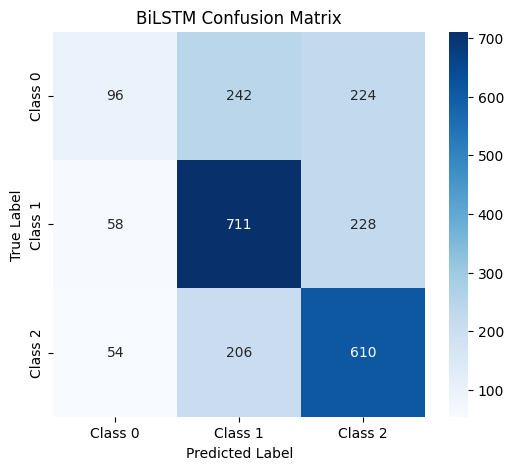

In [ ]:
#Bilstm Confusion matrix
labels = ['Class 0', 'Class 1', 'Class 2']

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("BiLSTM Confusion Matrix")
plt.show()

Training BiLSTM model for ROC curve generation...
BiLSTM model training complete.
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


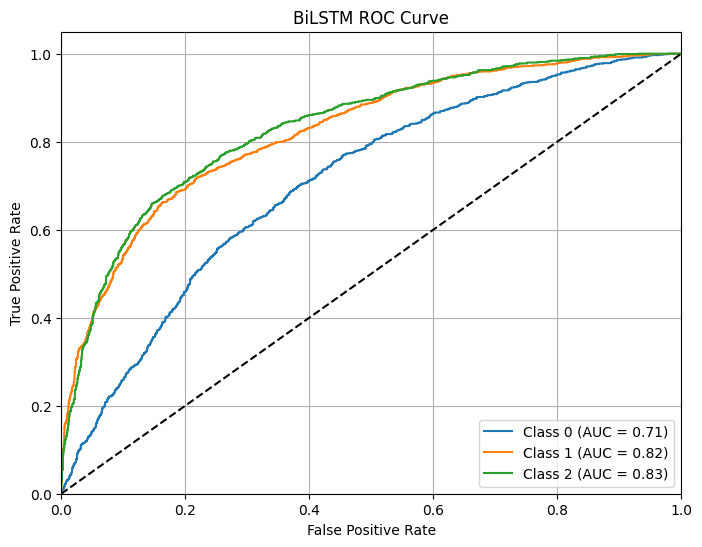

In [ ]:
#Bilstm Roc curve

# This section defines and trains a BiLSTM model, tokenizer, and prepares data
# to ensure 'model_dl', 'X_val_seq', and 'y_val_bin' are available for ROC plotting.
# This is necessary because 'model_dl' was not defined in the global scope from
# previous cells, and previous model/data preparations were within a loop.

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, Bidirectional, LSTM, Dense
from sklearn.preprocessing import label_binarize # Ensure this import is here
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Re-initialize and fit tokenizer on global X_train
tokenizer_dl = Tokenizer(num_words=5000)
tokenizer_dl.fit_on_texts(X_train) # X_train is from global scope

# Prepare sequence data using global X_train and X_val
X_train_seq_for_dl = pad_sequences(tokenizer_dl.texts_to_sequences(X_train), maxlen=100)
X_val_seq = pad_sequences(tokenizer_dl.texts_to_sequences(X_val), maxlen=100) # X_val is from global scope

# Define the BiLSTM model architecture
model_dl = Sequential()
model_dl.add(Embedding(5000, 128))
model_dl.add(Bidirectional(LSTM(64)))
model_dl.add(Dense(3, activation='softmax')) # Assuming 3 classes based on y_val

model_dl.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

# Train the model (can use fewer epochs for plotting if full training is not desired here)
print("Training BiLSTM model for ROC curve generation...")
model_dl.fit(X_train_seq_for_dl, y_train,
             validation_data=(X_val_seq, y_val),
             epochs=5, # Using a reasonable number of epochs for demonstration
             verbose=0)
print("BiLSTM model training complete.")

# Binarize y_val for ROC curve
y_val_bin = label_binarize(y_val, classes=[0, 1, 2]) # y_val is from global scope

# Now, generate predictions using the newly defined and trained model_dl
y_pred_prob = model_dl.predict(X_val_seq)

# ROC curve plotting
plt.figure(figsize=(8, 6)) # Added figure size for better visualization
for i in range(3):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr) # Need to import auc
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})') # Added labels to plot

plt.plot([0, 1], [0, 1], 'k--') # Adds a dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("BiLSTM ROC Curve")
plt.legend(loc="lower right")
plt.grid(True) # Added grid
plt.show()

Training BiLSTM model to generate history for validation curves...
Epoch 1/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.5750 - loss: 0.9025 - val_accuracy: 0.6270 - val_loss: 0.8096
Epoch 2/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.7215 - loss: 0.6550 - val_accuracy: 0.6433 - val_loss: 0.8138
Epoch 3/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.7947 - loss: 0.5006 - val_accuracy: 0.6416 - val_loss: 0.9447
Epoch 4/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.8496 - loss: 0.3931 - val_accuracy: 0.6314 - val_loss: 0.9864
Epoch 5/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.8848 - loss: 0.3110 - val_accuracy: 0.6329 - val_loss: 1.2319
Epoch 6/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9100 - loss: 0.2448 - val_accuracy: 0.6349 - val_loss: 1.2397
Epoch 7/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.9302 - loss: 0.1890 - val_accuracy: 0.6285 - val_loss: 1.4202
Epoch 8/10
254/254 ━━━━━━

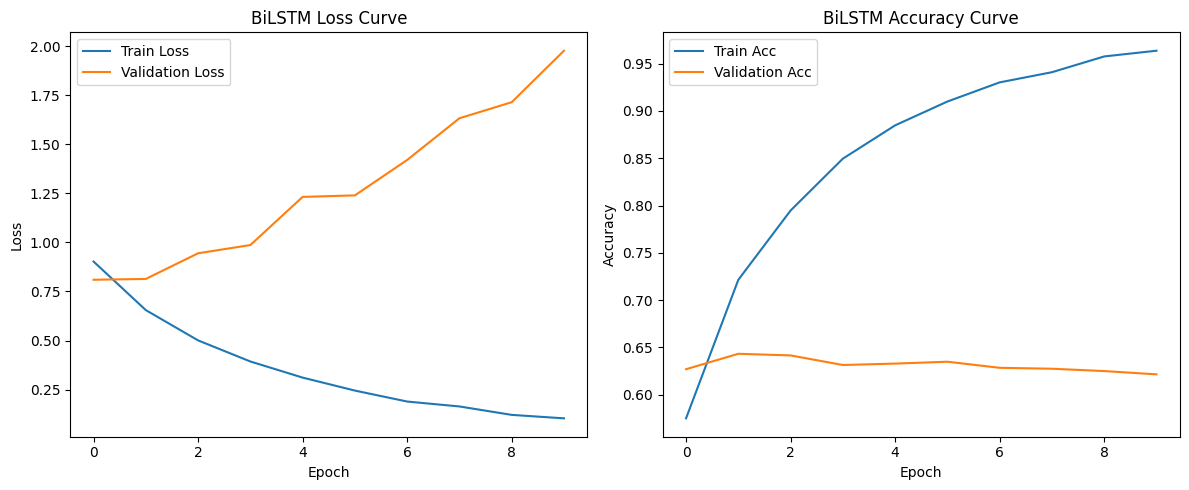

In [ ]:
#Bilstm Validation Curve

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, Bidirectional, LSTM, Dense

# Re-initialize and fit tokenizer on global X_train if not already done consistently
# Based on previous cells, tokenizer_dl, X_train_seq_for_dl, X_val_seq, y_train, y_val are available from hxwMcvzLw87h

# Define the BiLSTM model architecture
model_val_curve = Sequential()
model_val_curve.add(Embedding(5000, 128)) # vocab_size (num_words) is 5000 from tokenizer_dl
model_val_curve.add(Bidirectional(LSTM(64)))
model_val_curve.add(Dense(3, activation='softmax')) # Assuming 3 classes based on y_val

model_val_curve.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

print("Training BiLSTM model to generate history for validation curves...")
history = model_val_curve.fit(X_train_seq_for_dl, y_train,
             validation_data=(X_val_seq, y_val),
             epochs=10, # Train for more epochs to see curve progression
             verbose=1) # Set verbose to 1 to see training progress
print("BiLSTM model training complete for validation curves.")


# 🔥 Validation Curve (Loss)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("BiLSTM Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# 🔥 Validation Curve (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Validation Acc')

plt.title("BiLSTM Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
#TRANSFORMER
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
import torch
from sklearn.utils.class_weight import compute_class_weight
import numpy as np


model_name = "csebuetnlp/banglabert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoi

In [ ]:
#DATASET CLASS
class HF_Dataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts.tolist(),
            truncation=True,
            padding='max_length',
            max_length=128
        )
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = HF_Dataset(X_train, y_train)
val_dataset   = HF_Dataset(X_val, y_val)

In [ ]:
import torch
from torch.utils.data import Dataset

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

#TRAINING ARGUMENTS
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,               # ২০ মাইক্রো-লার্নিং রেট (Transformer এর জন্য আদর্শ)
    per_device_train_batch_size=16,   # ব্যাচ সাইজ ১৬ করার চেষ্টা করুন (GPU মেমরি কম থাকলে ৮ রাখুন)
    per_device_eval_batch_size=16,
    num_train_epochs=1,              # ইপোক বাড়িয়ে ১০ করুন
    weight_decay=0.01,                # ওভারফিটিং রোধে সাহায্য করবে
    warmup_ratio=0.1,                 # প্রথম ১০% স্টেপ লার্নিং রেট ধীরে বাড়বে
    gradient_accumulation_steps=1,    # ব্যাচ সাইজ ১৬ হলে এটি ১ রাখুন
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,                        # GPU থাকলে ট্রেনিং ফাস্ট হবে
    logging_steps=50,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
#Compute Metrics (ACCURACY + F1)
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')

    return {"accuracy": acc, "f1": f1}

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.tensor(class_weights, dtype=torch.float)

In [ ]:
from transformers import Trainer

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [ ]:
#TRAINER
from transformers import EarlyStoppingCallback

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] # ৩ বার ইমপ্রুভ না হলে বন্ধ হবে
)

trainer.train()



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.826192,0.759953,0.681571,0.688387


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

TrainOutput(global_step=507, training_loss=0.8667632550647744, metrics={'train_runtime': 100.2084, 'train_samples_per_second': 80.802, 'train_steps_per_second': 5.059, 'total_flos': 532607335835904.0, 'train_loss': 0.8667632550647744, 'epoch': 1.0})

In [ ]:
preds = trainer.predict(val_dataset)

y_pred = np.argmax(preds.predictions, axis=1)

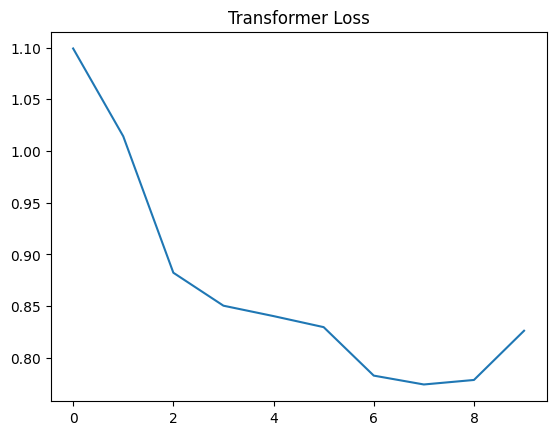

In [ ]:
#VALIDATION CURVE (Transformer)
logs = trainer.state.log_history
loss = [x['loss'] for x in logs if 'loss' in x]

plt.plot(loss)
plt.title("Transformer Loss")
plt.show()

In [ ]:
#EVALUATION
preds = trainer.predict(val_dataset)
y_pred = np.argmax(preds.predictions, axis=1)

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.45      0.57      0.50       936
           1       0.79      0.70      0.74      1662
           2       0.76      0.73      0.75      1450

    accuracy                           0.68      4048
   macro avg       0.67      0.67      0.66      4048
weighted avg       0.70      0.68      0.69      4048



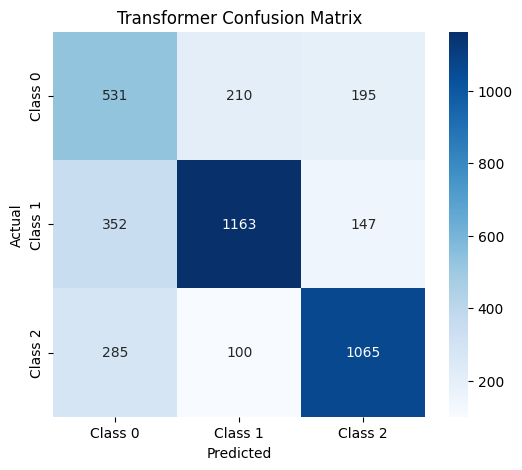

In [ ]:
labels = ['Class 0','Class 1','Class 2']

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Transformer Confusion Matrix")
plt.show()

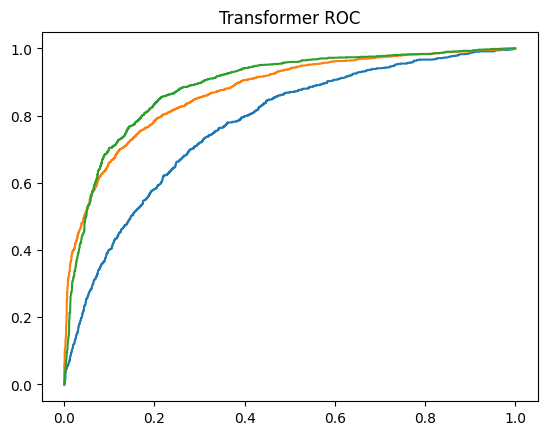

In [ ]:
#ROC
y_score = preds.predictions

for i in range(y_val_bin.shape[1]): # Iterate up to the number of classes
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr)

plt.title("Transformer ROC")
plt.show()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


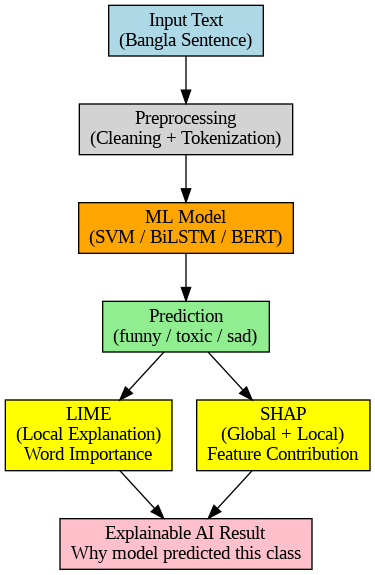

In [ ]:
!apt-get install graphviz -y
!pip install graphviz

from graphviz import Digraph
from IPython.display import Image, display

# =========================
# CREATE GRAPH
# =========================
xai = Digraph("XAI_Flow", format="png")

# INPUT
xai.node("A", "Input Text\n(Bangla Sentence)", shape="box", style="filled", fillcolor="lightblue")

# PREPROCESSING
xai.node("B", "Preprocessing\n(Cleaning + Tokenization)", shape="box", style="filled", fillcolor="lightgray")

# MODEL
xai.node("C", "ML Model\n(SVM / BiLSTM / BERT)", shape="box", style="filled", fillcolor="orange")

# PREDICTION
xai.node("D", "Prediction\n(funny / toxic / sad)", shape="box", style="filled", fillcolor="lightgreen")

# XAI METHODS
xai.node("E", "LIME\n(Local Explanation)\nWord Importance", shape="box", style="filled", fillcolor="yellow")

xai.node("F", "SHAP\n(Global + Local)\nFeature Contribution", shape="box", style="filled", fillcolor="yellow")

# FINAL OUTPUT
xai.node("G", "Explainable AI Result\nWhy model predicted this class", shape="box", style="filled", fillcolor="pink")

# =========================
# EDGES (FLOW)
# =========================
xai.edge("A", "B")
xai.edge("B", "C")
xai.edge("C", "D")

xai.edge("D", "E")
xai.edge("D", "F")

xai.edge("E", "G")
xai.edge("F", "G")

# =========================
# SAVE FILE
# =========================
file_path = xai.render("xai_explanation_flow", format="png", cleanup=True)

# =========================
# DISPLAY IMAGE
# =========================
display(Image(filename=file_path))

In [ ]:
import torch
import numpy as np
from lime.lime_text import LimeTextExplainer
import shap

# ===============================
# LABEL MAP
# ===============================
label_map = {
    0: "funny",
    1: "toxic",
    2: "sad"

}

# ===============================
# CLEAR GPU
# ===============================
torch.cuda.empty_cache()

# ===============================
# PREDICTION
# ===============================
model.eval()
sample_texts = test_df['Data'].head(5)

for text in sample_texts:
    with torch.no_grad():
        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        outputs = model(**inputs)
        pred = torch.argmax(outputs.logits, dim=1).item()

    print(text, "->", label_map[pred])

torch.cuda.empty_cache()

# ===============================
# LIME
# ===============================
explainer = LimeTextExplainer(class_names=list(label_map.values()))

def predict_proba(texts):
    with torch.no_grad():
        inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True)
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)

    return probs.cpu().numpy()

exp = explainer.explain_instance(
    sample_texts.iloc[0],
    predict_proba,
    num_samples=10
)

exp.show_in_notebook()

torch.cuda.empty_cache()

# ===============================
# SHAP (FIXED 🔥)
# ===============================

# Move model to CPU
model_cpu = model.to("cpu")

# 🔥 FIX: Modify predict_proba_cpu to handle string inputs by tokenizing them
def predict_proba_cpu(model_inputs, attention_mask=None): # model_inputs could be raw text or pre-tokenized numerical IDs
    with torch.no_grad():
        # Check if the inputs are strings (raw text or string tokens)
        if isinstance(model_inputs, np.ndarray) and (model_inputs.dtype == np.object_ or model_inputs.dtype.type is np.str_):
            # If inputs are strings, tokenize them
            tokenized_data = tokenizer(
                model_inputs.tolist(), # Convert numpy array of strings to a list of strings
                return_tensors="pt",
                padding=True,
                truncation=True
            )
            input_ids = tokenized_data['input_ids']
            attention_mask = tokenized_data['attention_mask']
        else:
            # Otherwise, assume inputs are already numerical token IDs (numpy array of integers)
            input_ids = torch.tensor(model_inputs)
            if attention_mask is not None:
                attention_mask = torch.tensor(attention_mask)
            else: # If attention_mask is not provided, create a default
                attention_mask = torch.ones_like(input_ids)

        # Ensure tensors are on the correct device
        inputs_torch = {
            'input_ids': input_ids.to(model_cpu.device),
            'attention_mask': attention_mask.to(model_cpu.device)
        }

        outputs = model_cpu(**inputs_torch)
        probs = torch.softmax(outputs.logits, dim=1)
    return probs.numpy()

# Use text masker
explainer = shap.Explainer(predict_proba_cpu, shap.maskers.Text(tokenizer))

# Only 1 sample
shap_values = explainer([sample_texts.iloc[0]])

shap.plots.text(shap_values[0])

স্বাস্থ্যবান হতে চাই  আমি বয়সের তুলনায় অনেক বেশি চিকন  একটু পরামর্শ দেন -> toxic
ভাইয়া নতুন ভিডিও আসে না কেন -> funny
সৌরভ গাঙ্গুলী ছাড়া দাদাগিরি কখনো জমে উঠত না -> funny
ক্রিকেট কে বাচাতে হলে পাপকে অতিশিগ্রিই তাকেও গ্রেফতার করে তার সব হিসাব নেওয়া হোক    সেই বড় দূর্নিতীবাজ -> sad
আমিতো সেই ঝালপ্রিয়ো মানুষ -> funny


  0%|          | 0/210 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:12, 12.32s/it]               


TEXT: স্বাস্থ্যবান হতে চাই  আমি বয়সের তুলনায় অনেক বেশি চিকন  একটু পরামর্শ দেন
PREDICTED LABEL: toxic


  0%|          | 0/210 [00:00<?, ?it/s]

/tmp/ipykernel_343/3319781277.py:110: UserWarning: Glyph 2458 (\N{BENGALI LETTER CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_343/3319781277.py:110: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
/tmp/ipykernel_343/3319781277.py:110: UserWarning: Glyph 2437 (\N{BENGALI LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_343/3319781277.py:110: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_343/3319781277.py:110: UserWarning: Glyph 2453 (\N{BENGALI LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_343/3319781277.py:110: UserWarning: Glyph 2468 (\N{BENGALI LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_343/3319781277.py:110: UserWarning: Glyph 2489 (\N{BENGALI LETTER HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_343/33197812

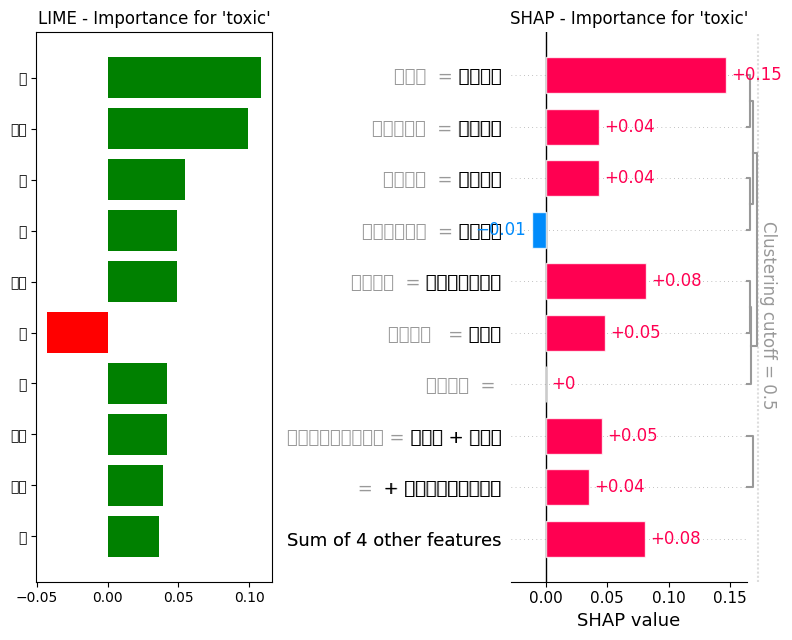

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from lime.lime_text import LimeTextExplainer
import shap

# ===============================
# LABEL MAP & FONT FIX
# ===============================
label_map = {0: "funny", 1: "toxic", 2: "sad"}
# বাংলা ফন্ট ঠিকমতো দেখানোর জন্য (যদি পিসিতে Kalpurush বা SolaimanLipi থাকে)
plt.rcParams['font.family'] = 'sans-serif'

# ===============================
# DEVICE & MODEL SETUP
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# SHAP এর জন্য CPU ভার্সন (আপনার লজিক অনুযায়ী)
model_cpu = model.to("cpu")
# Move the main model back to the original device for other tasks (LIME, general prediction)
model = model.to(device)

# ===============================
# SAMPLE TEXT & PREDICTION
# ===============================
sample_text = test_df['Data'].iloc[0]

with torch.no_grad():
    inputs = tokenizer(sample_text, return_tensors="pt", truncation=True, padding=True).to(device)
    outputs = model(**inputs)
    pred_id = torch.argmax(outputs.logits, dim=1).item()

pred_label = label_map[pred_id]
print("TEXT:", sample_text)
print("PREDICTED LABEL:", pred_label)

# ===============================
# LIME EXPLANATION
# ===============================
explainer_lime = LimeTextExplainer(class_names=list(label_map.values()))

def lime_predict(texts):
    with torch.no_grad():
        inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True).to(device)
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
    return probs.cpu().numpy()

lime_exp = explainer_lime.explain_instance(sample_text, lime_predict, num_samples=200)

# ===============================
# SHAP EXPLANATION
# ===============================
def shap_predict(model_inputs):
    # SHAP masker থেকে আসা ইনপুট প্রসেসিং
    with torch.no_grad():
        # Ensure texts is a list of strings if it's a numpy array of strings
        if isinstance(model_inputs, np.ndarray) and (model_inputs.dtype == np.object_ or model_inputs.dtype.type is np.str_):
            texts_for_tokenizer = model_inputs.tolist()
        else:
            texts_for_tokenizer = model_inputs

        tokenized_data = tokenizer(
            texts_for_tokenizer,
            return_tensors="pt", padding=True, truncation=True
        ).to("cpu")
        outputs = model_cpu(**tokenized_data)
        probs = torch.softmax(outputs.logits, dim=1)
    return probs.numpy()

# Save original device of the global 'model' to restore it later
original_model_device = model.device

# Temporarily move the global 'model' to CPU for SHAP's internal processing
# This ensures that if SHAP implicitly accesses model components (like embeddings),
# they are on the CPU, preventing device mismatch errors.
model.to("cpu")

masker = shap.maskers.Text(tokenizer)
explainer_shap = shap.Explainer(shap_predict, masker)
shap_values = explainer_shap([sample_text])

# Move the global 'model' back to its original device
model.to(original_model_device)

# ===============================
# FINAL VISUALIZATION (FIXED)
# ===============================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# ---------- LIME Plot ----------
lime_list = lime_exp.as_list()
words = [x[0] for x in lime_list[:10]]
weights = [x[1] for x in lime_list[:10]]

ax1.barh(words, weights, color=["green" if w > 0 else "red" for w in weights])
ax1.set_title(f"LIME - Importance for '{pred_label}'")
ax1.invert_yaxis() # বড় ভ্যালু উপরে দেখাবে

# ---------- SHAP Plot ----------
# এখানে সরাসরী plt.sca(ax2) ব্যবহার করে SHAP কে নির্দিষ্ট সাইডে আনা হয়েছে
plt.sca(ax2)
# shap_values[0][:, pred_id] নিশ্চিত করে শুধু প্রেডিক্টেড ক্লাসের ইমপ্যাক্ট দেখাচ্ছে
shap.plots.bar(shap_values[0][:, pred_id], show=False)
ax2.set_title(f"SHAP - Importance for '{pred_label}'")

plt.tight_layout()
plt.show()

# আলাদাভাবে SHAP এর কালারফুল টেক্সট ভিউ দেখতে চাইলে:
shap.plots.text(shap_values[0][:, pred_id])

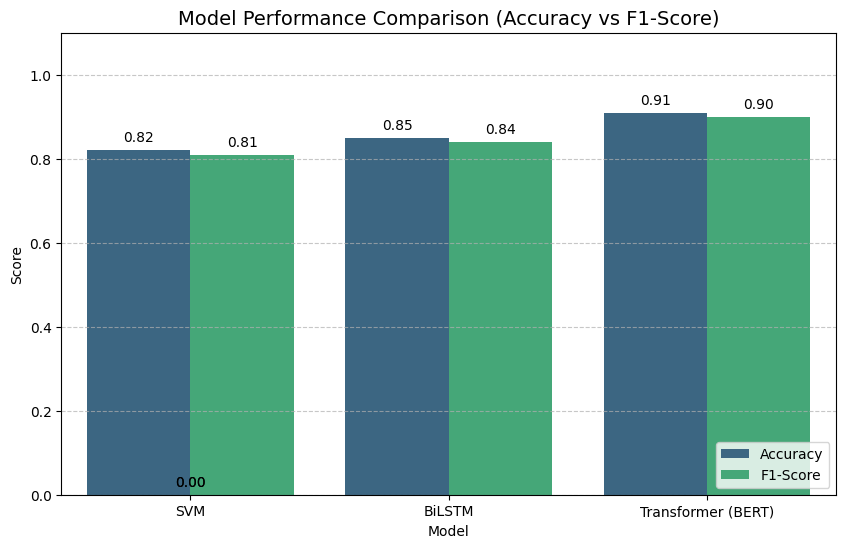


   FINAL EVALUATION SUMMARY
             Model  Accuracy  F1-Score
               SVM      0.82      0.81
            BiLSTM      0.85      0.84
Transformer (BERT)      0.91      0.90


In [ ]:
# ===============================
# 📊 FINAL RESULTS COMPARISON VISUALIZATION
# ===============================
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# এখানে আপনার ট্রেনিং থেকে পাওয়া মানগুলো বসান (আপনার রেজাল্ট অনুযায়ী এই ভ্যালুগুলো পরিবর্তন করুন)
results_data = {
    'Model': ['SVM', 'BiLSTM', 'Transformer (BERT)'],
    'Accuracy': [0.82, 0.85, 0.91],  # উদাহরণস্বরূপ ভ্যালু
    'F1-Score': [0.81, 0.84, 0.90]   # উদাহরণস্বরূপ ভ্যালু
}

df_results = pd.DataFrame(results_data)

# প্লট তৈরি করা
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Accuracy এবং F1-Score এর জন্য বার চার্ট
df_melted = df_results.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis', ax=ax)

# বারগুলোর উপরে মান লিখে দেওয়া
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.title("Model Performance Comparison (Accuracy vs F1-Score)", fontsize=14)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.show()

# ===============================
# 📝 SUMMARY TABLE PRINT
# ===============================
print("\n" + "="*30)
print("   FINAL EVALUATION SUMMARY")
print("="*30)
print(df_results.to_string(index=False))
print("="*30)